In [1]:
import rsgislib
print("rsgislib se importó correctamente. Versión:", rsgislib.__version__)

rsgislib se importó correctamente. Versión: 5.1.7


In [2]:
import geopandas
print("geopandas se importó correctamente. Versión:", geopandas.__version__)

geopandas se importó correctamente. Versión: 1.0.1


In [3]:
!pip install matplotlib-scalebar

In [4]:
# Import modules from python standard library
import os
import pprint
import random

# Import Geopandas for vector analysis (https://geopandas.org)
import geopandas

# Import the matplotlib plotting module and set it to work within
# a notebook environment.
%matplotlib inline
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# Import the RSGISLib modules for the notebook
import rsgislib
import rsgislib.classification
import rsgislib.classification.classsklearn
import rsgislib.tools.filetools
import rsgislib.tools.mapping
import rsgislib.tools.plotting
import rsgislib.vectorutils
import rsgislib.zonalstats
from sklearn.ensemble import RandomForestClassifier

# scikit-learn imports
from sklearn.model_selection import GridSearchCV

In [5]:
# Input Sentinel-2 image file with 20 m resolution pixels.
input_img = "./DATOS_OUR/sentinel2_2018_input_img.tif"

# A valid pixel mask for the input image - this is required for later
# steps but note that for this particular image all the pixel values
# are valid (i.e., there aren't are no data regions).
in_msk_img = "./DATOS_OUR/sentinel2_2018_in_msk_img.tif"

vec_train_file = "./DATOS_OUR/Training/Training.shp"

In [6]:
import geopandas as gpd
# Leer shapefile
gdf = gpd.read_file(vec_train_file)

# Mostrar las columnas disponibles
print(gdf.columns)

# Mostrar los valores únicos de la columna 'Name'
print(gdf['Name'].unique())

Index(['fid_', 'Name', 'descriptio', 'timestamp', 'begin', 'end', 'altitudeMo',
       'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'landcover',
       'system_ind', 'geometry'],
      dtype='object')
['Agricultural_areas' 'Forest' 'Water_bodies' 'Secondary_vegetation'
 'sparsely or no vegetated areas']


In [7]:
# Get the full image bounding box.
img_bbox = rsgislib.imageutils.get_img_bbox(input_img)
print(img_bbox)

(-75.19599614002009, -74.36074258884575, 0.1976293625062946, 1.0711511447841173)


Bounding box de la imagen: (-75.19599614002009, -74.36074258884575, 0.1976293625062946, 1.0711511447841173)
Image Data Size: 4649 x 4862


/opt/conda/envs/geo_env/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/opt/conda/envs/geo_env/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/opt/conda/envs/geo_env/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/opt/conda/envs/geo_env/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizon

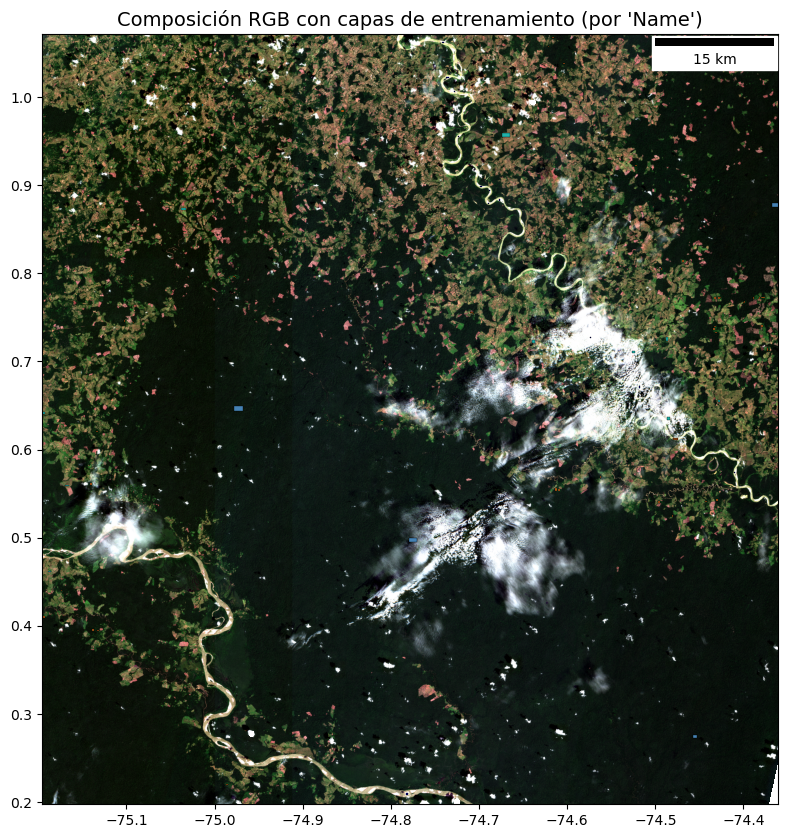

In [8]:
# 1. Obtener el bounding box completo de la imagen 
img_bbox = rsgislib.imageutils.get_img_bbox(input_img)
print("Bounding box de la imagen:", img_bbox)

# 2. Prepara el canvas de Matplotlib
fig, ax = plt.subplots(figsize=(10, 10))

# 3. Dibuja la imagen RGB de Sentinel-2 
rsgislib.tools.mapping.create_raster_img_map(
    ax,
    input_img,
    img_bands=[3, 2, 1],
    img_stch=rsgislib.IMG_STRETCH_CUMULATIVE,
    bbox=img_bbox,
    show_scale_bar=True
)

# 4. Genera colores aleatorios para clases
mpl_clrs = list(mcolors.CSS4_COLORS.keys())
gp_vecs = []
lyr_clrs = []

# Obtener los nombres únicos de clase en 'Name'
unique_names = gdf['Name'].unique()

# Crear un GeoDataFrame por clase
for name in unique_names:
    gdf_class = gdf[gdf['Name'] == name]
    gp_vecs.append(gdf_class)
    lyr_clrs.append(random.choice(mpl_clrs))

# 6. Superponer los vectores sobre la imagen
rsgislib.tools.mapping.create_vec_lyr_map(
    ax,
    gp_vecs=gp_vecs,
    bbox=img_bbox,
    vec_fill_clrs=lyr_clrs,
    vec_line_clrs='black',
    show_scale_bar=False
)

# 7. Mostrar el resultado
plt.title("Composición RGB con capas de entrenamiento (por 'Name')", fontsize=14)
plt.show()

In [9]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 7.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [rasterio]4/5 [rasterio]


In [10]:
import rasterio

# Abrir la imagen
with rasterio.open("./DATOS_OUR/sentinel2_2018_input_img.tif") as src:
    print(f"Cantidad de bandas: {src.count}")
    for i in range(1, src.count + 1):
        print(f"Banda {i}: dtype={src.dtypes[i-1]}, shape={src.read(i).shape}")

Cantidad de bandas: 6
Banda 1: dtype=float32, shape=(4862, 4649)
Banda 2: dtype=float32, shape=(4862, 4649)
Banda 3: dtype=float32, shape=(4862, 4649)
Banda 4: dtype=float32, shape=(4862, 4649)
Banda 5: dtype=float32, shape=(4862, 4649)
Banda 6: dtype=float32, shape=(4862, 4649)


In [11]:
img_band_info = list()
img_band_info.append(
    rsgislib.imageutils.ImageBandInfo(
        file_name=input_img, name="sen2", bands=[1, 2, 3, 4, 5, 6]
    )
)
print(img_band_info)

[('sen2', [1, 2, 3, 4, 5, 6], './DATOS_OUR/sentinel2_2018_input_img.tif')]


In [12]:
# Revisar columnas
print("Columnas disponibles:", gdf.columns)

# Ver valores únicos de clases
print(gdf[['landcover', 'Name']].drop_duplicates())

Columnas disponibles: Index(['fid_', 'Name', 'descriptio', 'timestamp', 'begin', 'end', 'altitudeMo',
       'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'landcover',
       'system_ind', 'geometry'],
      dtype='object')
   landcover                            Name
0          1              Agricultural_areas
12         2                          Forest
16         5                    Water_bodies
21         6            Secondary_vegetation
74         8  sparsely or no vegetated areas


In [14]:
!pip install fiona

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 8.0 MB/s eta 0:00:00a 0:00:01


In [15]:
import fiona
with fiona.open(vec_train_file, 'r') as src:
    print("Nombre(s) de la(s) capa(s):", src.name)

Nombre(s) de la(s) capa(s): Training


In [16]:
from rsgislib.classification import ClassVecSamplesInfoObj

vec_train_file = "./DATOS_OUR/Training/Training.shp"

class_vec_sample_info = [
    ClassVecSamplesInfoObj(
        id=1,
        class_name="agricultural_areas",
        vec_file=vec_train_file,
        vec_lyr="Training",
        file_h5="agricultural_areas_smpls.h5"
    ),
    ClassVecSamplesInfoObj(
        id=2,
        class_name="forest",
        vec_file=vec_train_file,
        vec_lyr="Training",
        file_h5="forest_smpls.h5"
    ),
    ClassVecSamplesInfoObj(
        id=5,
        class_name="water_bodies",
        vec_file=vec_train_file,
        vec_lyr="Training",
        file_h5="water_bodies_smpls.h5"
    ),
    ClassVecSamplesInfoObj(
        id=6,
        class_name="secondary_vegetation",
        vec_file=vec_train_file,
        vec_lyr="Training",
        file_h5="secondary_vegetation_smpls.h5"
    ),
    ClassVecSamplesInfoObj(
        id=8,
        class_name="sparsely_or_no_vegetated_areas",
        vec_file=vec_train_file,
        vec_lyr="Training",
        file_h5="sparsely_or_no_vegetated_areas_smpls.h5"
    ),
]

print(class_vec_sample_info)

[<rsgislib.classification.ClassVecSamplesInfoObj object at 0x7f87cbdd6490>, <rsgislib.classification.ClassVecSamplesInfoObj object at 0x7f87cbdd64c0>, <rsgislib.classification.ClassVecSamplesInfoObj object at 0x7f87cbdd6520>, <rsgislib.classification.ClassVecSamplesInfoObj object at 0x7f87cbdd6a60>, <rsgislib.classification.ClassVecSamplesInfoObj object at 0x7f87cbdd6d90>]


In [17]:
obj = class_vec_sample_info[0]
vars(obj)        # returns a dictionary of attributes
# or
obj.__dict__

{'id': 1,
 'class_name': 'agricultural_areas',
 'vec_file': './DATOS_OUR/Training/Training.shp',
 'vec_lyr': 'Training',
 'file_h5': 'agricultural_areas_smpls.h5'}

In [18]:
tmp_dir = "./tmp"

if not os.path.exists(tmp_dir):
    os.mkdir(tmp_dir)

In [19]:
cls_smpls_info = rsgislib.classification.get_class_training_data(
    img_band_info, class_vec_sample_info, tmp_dir, ref_img=in_msk_img
)

Creating output image using input image
Running Rasterise now...

Get Image Min and Max.

Get Image Histogram.

Adding Histogram and Colour Table to image file
Calculating Image Pyramids.


Creating output image using input image

Running Rasterise now...
Get Image Min and Max.

Get Image Histogram.

Adding Histogram and Colour Table to image file
Calculating Image Pyramids.


Creating output image using input image
Running Rasterise now...

Get Image Min and Max.

Creating output image using input image
Get Image Histogram.

Adding Histogram and Colour Table to image file
Calculating Image Pyramids.



Running Rasterise now...
Get Image Min and Max.

Get Image Histogram.

Adding Histogram and Colour Table to image file
Calculating Image Pyramids.


Creating output image using input image

Running Rasterise now...
Get Image Min and Max.

Get Image Histogram.

Adding Histogram and Colour Table to image file
Calculating Image Pyramids.




In [20]:
# Output the returned class samples info object 
cls_smpls_info

{'agricultural_areas': 1: agricultural_areas_smpls.h5, (249, 48, 79),
 'forest': 2: forest_smpls.h5, (62, 153, 221),
 'water_bodies': 5: water_bodies_smpls.h5, (229, 45, 100),
 'secondary_vegetation': 6: secondary_vegetation_smpls.h5, (57, 215, 148),
 'sparsely_or_no_vegetated_areas': 8: sparsely_or_no_vegetated_areas_smpls.h5, (160, 219, 145)}

In [21]:
# Diccionario de colores RGB por clase (adaptado a tus nombres)
color_dict = {
    "agricultural_areas": (180, 180, 180),
    "forest": (0, 105, 16),
    "water_bodies": (0, 0, 255),
    "secondary_vegetation": (62, 168, 78),
    "sparsely_or_no_vegetated_areas": (252, 231, 109),
}

# Recorremos y asignamos los colores
for cls_obj in class_vec_sample_info:
    cname = cls_obj.class_name
    if cname in color_dict:
        r, g, b = color_dict[cname]
        cls_obj.red = r
        cls_obj.green = g
        cls_obj.blue = b
    else:
        # Asigna un color default si quieres, por ejemplo gris
        cls_obj.red = 150
        cls_obj.green = 150
        cls_obj.blue = 150

# Revisar resultados
for cls_obj in class_vec_sample_info:
    print(f"{cls_obj.class_name}: R={cls_obj.red}, G={cls_obj.green}, B={cls_obj.blue}")

agricultural_areas: R=180, G=180, B=180
forest: R=0, G=105, B=16
water_bodies: R=0, G=0, B=255
secondary_vegetation: R=62, G=168, B=78
sparsely_or_no_vegetated_areas: R=252, G=231, B=109


In [22]:
for cls_name in cls_smpls_info:
    smpls_h5_file = cls_smpls_info[cls_name].file_h5
    n_smpls = rsgislib.classification.get_num_samples(smpls_h5_file)
    print(f"{cls_name}: {n_smpls}")

agricultural_areas: 14863
forest: 14863
water_bodies: 14863
secondary_vegetation: 14863
sparsely_or_no_vegetated_areas: 14863


In [23]:
# Define the output directory and create if it does not exist:
smpls_dir = "./cls_smpls"

if not os.path.exists(smpls_dir):
    os.mkdir(smpls_dir)


cls_smpls_fnl_info = rsgislib.classification.get_class_info_dict(
    cls_smpls_info, smpls_dir
)

print("\n keys",cls_smpls_fnl_info.keys())

# print the values of artificail_surfaces
print("\n keys",cls_smpls_fnl_info["agricultural_areas"])

0=1: (Train:./cls_smpls/agricultural_areas_smpls_train.h5, Test:./cls_smpls/agricultural_areas_smpls_test.h5, Valid:./cls_smpls/agricultural_areas_smpls_valid.h5), (249, 48, 79)
1=2: (Train:./cls_smpls/forest_smpls_train.h5, Test:./cls_smpls/forest_smpls_test.h5, Valid:./cls_smpls/forest_smpls_valid.h5), (62, 153, 221)
2=5: (Train:./cls_smpls/water_bodies_smpls_train.h5, Test:./cls_smpls/water_bodies_smpls_test.h5, Valid:./cls_smpls/water_bodies_smpls_valid.h5), (229, 45, 100)
3=6: (Train:./cls_smpls/secondary_vegetation_smpls_train.h5, Test:./cls_smpls/secondary_vegetation_smpls_test.h5, Valid:./cls_smpls/secondary_vegetation_smpls_valid.h5), (57, 215, 148)
4=8: (Train:./cls_smpls/sparsely_or_no_vegetated_areas_smpls_train.h5, Test:./cls_smpls/sparsely_or_no_vegetated_areas_smpls_test.h5, Valid:./cls_smpls/sparsely_or_no_vegetated_areas_smpls_valid.h5), (160, 219, 145)

 keys dict_keys(['agricultural_areas', 'forest', 'water_bodies', 'secondary_vegetation', 'sparsely_or_no_vegetated_a

In [24]:
# Run the create_train_valid_test_sets helper function to
# create the train, valid and test datasets
rsgislib.classification.create_train_valid_test_sets(
    cls_smpls_info, cls_smpls_fnl_info, 50, 50, 350
)

In [25]:
!h5dump cls_smpls/agricultural_areas_smpls_valid.h5

HDF5 "cls_smpls/agricultural_areas_smpls_valid.h5" {
GROUP "/" {
   GROUP "DATA" {
      DATASET "DATA" {
         DATATYPE  H5T_IEEE_F32LE
         DATASPACE  SIMPLE { ( 59, 6 ) / ( H5S_UNLIMITED, 6 ) }
         DATA {
         (0,0): 1781, 2545, 3217, 3693, 5427, 5454,
         (1,0): 237, 479, 214, 4058, 1787, 741,
         (2,0): 248, 489, 227, 3978, 1941, 853,
         (3,0): 1996, 2685, 3260, 3593, 5314, 5333,
         (4,0): 427, 693, 627, 3013, 2525, 1380,
         (5,0): 423, 687, 610, 3140, 2478, 1316,
         (6,0): 351, 559, 525, 2605, 2307, 1279,
         (7,0): 376, 601, 583, 2661, 2563, 1459,
         (8,0): 1423, 2120, 2793, 3253, 5050, 4857,
         (9,0): 225, 430, 193, 3204, 1606, 708,
         (10,0): 1423, 2120, 2793, 3253, 5050, 4857,
         (11,0): 423, 689, 615, 3064, 2605, 1440,
         (12,0): 195, 373.5, 195, 2835.5, 1441.5, 561.5,
         (13,0): 188.5, 330, 189, 2598, 1435.5, 550,
         (14,0): 373, 635.5, 599, 2616.5, 2776, 1599,
         (15,0): 

In [26]:
grid_search = GridSearchCV(
    RandomForestClassifier(),
    param_grid={
        "n_estimators": [10, 20, 50, 100, 150, 200],
        "max_depth": [4, 8, 10, 12, 14, 16],
    },
)
print(grid_search )
sk_classifier = (
    rsgislib.classification.classsklearn.perform_sklearn_classifier_param_search(
        cls_smpls_fnl_info, grid_search
    )
)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_depth': [4, 8, 10, 12, 14, 16],
                         'n_estimators': [10, 20, 50, 100, 150, 200]})
Training data size: 295 x 6
Best score was 0.18983050847457625 and has parameters {'max_depth': 4, 'n_estimators': 10}.


In [27]:
rsgislib.classification.classsklearn.train_sklearn_classifier(
    cls_smpls_fnl_info, sk_classifier
)

Training data size: 1770 x 6
Testing data size: 295 x 6
Training Classifier
Completed
Calc Classifier Accuracy
Classifier Train Score = 20.0%
Classifier Test Score = 20.0%


(0.2, 0.2)

In [28]:
out_cls_img = "sen2_20180.kea"
out_scr_img = "sen2_20180_score.kea"

rsgislib.classification.classsklearn.apply_sklearn_classifier(
    cls_smpls_fnl_info,
    sk_classifier,
    in_msk_img=in_msk_img,
    img_msk_val=1,
    img_file_info=img_band_info,
    out_class_img=out_cls_img,
    gdalformat="KEA",
    class_clr_names=True,
    out_score_img=out_scr_img,
)

Applying the Classifier


  0%|          | 0/100 [00:00<?, ?it/s]

Completed
Get Image Min and Max.

Get Image Histogram.

Adding Histogram and Colour Table to image file
Calculating Image Pyramids.



Calculating Image Pyramids.





Apply Colour to class 'agricultural_areas'
Apply Colour to class 'forest'
Apply Colour to class 'water_bodies'
Apply Colour to class 'secondary_vegetation'
Apply Colour to class 'sparsely_or_no_vegetated_areas'


Image Data Size: 4649 x 4862


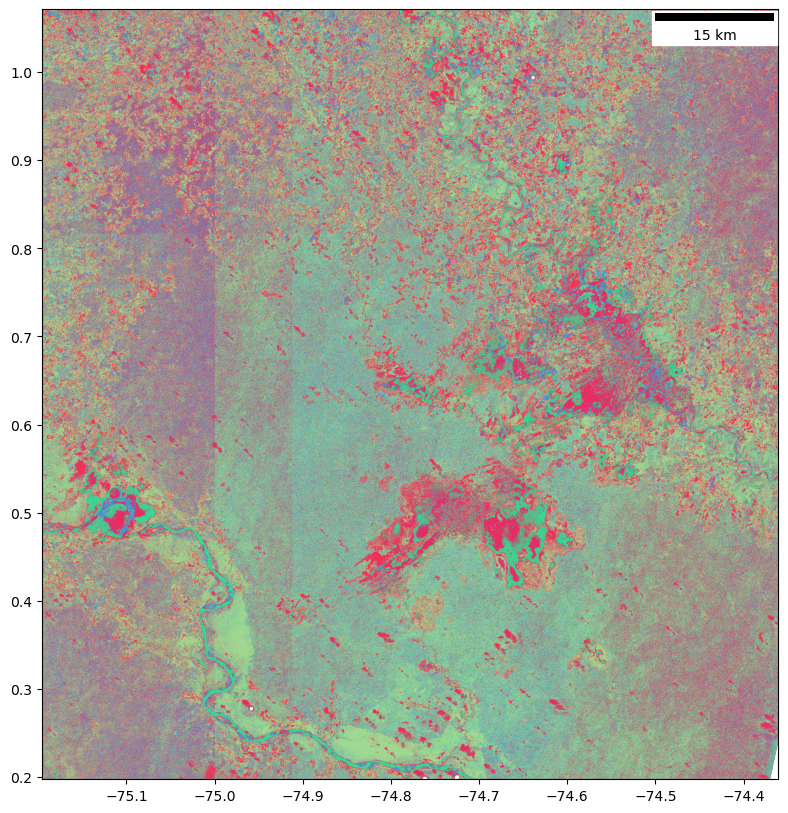

In [29]:
# Create the matplotlib figure
fig, ax = plt.subplots(figsize=(10, 10))

rsgislib.tools.mapping.create_thematic_raster_map(ax, out_cls_img)

Image Data Size: 2783 x 3339
Image Data Size: 2783 x 3339


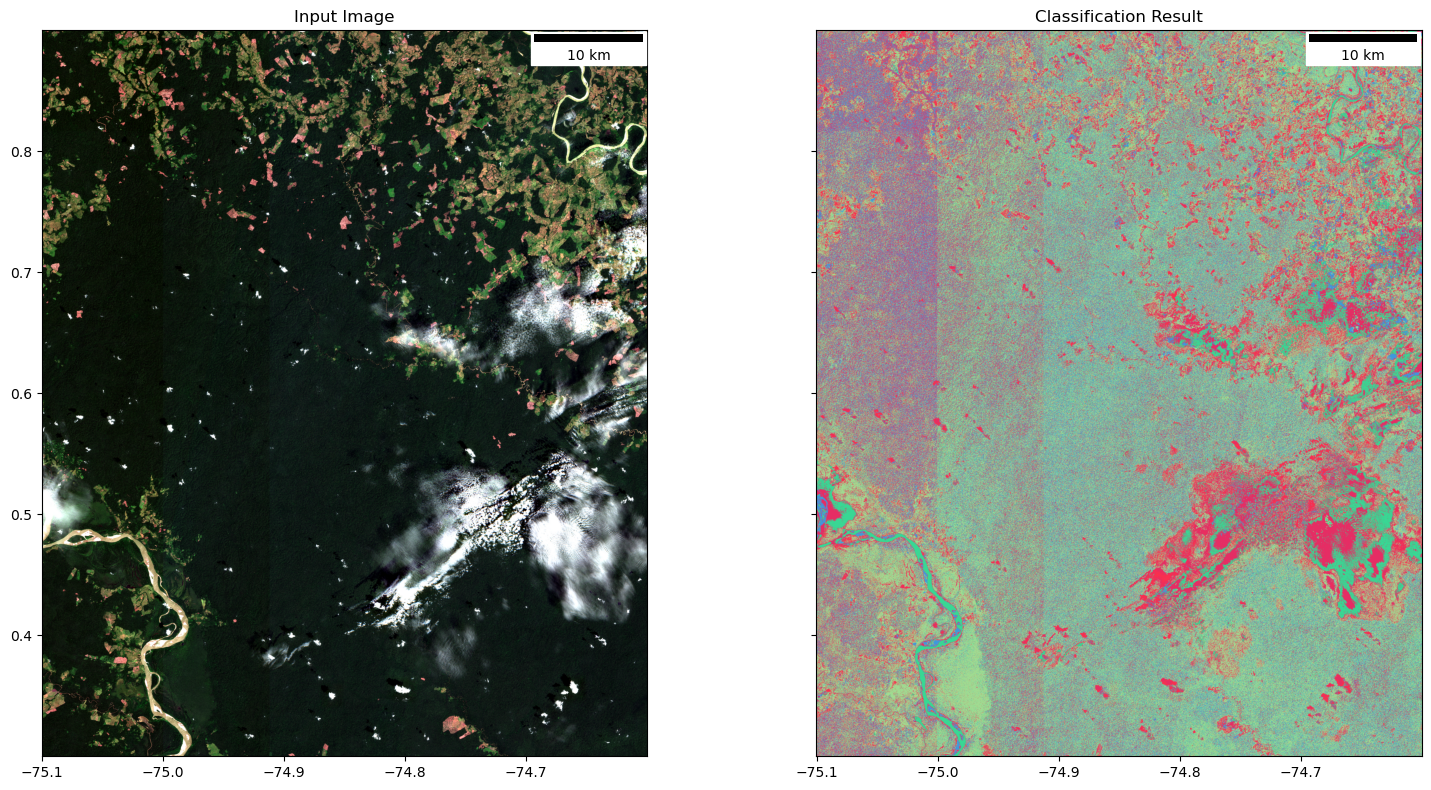

In [30]:
sub_img_bbox = [-75.1, -74.6, 0.3, 0.9]  # [xmin, xmax, ymin, ymax]

# Crear la figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Mostrar imagen Sentinel-2 en RGB falso color
rsgislib.tools.mapping.create_raster_img_map(
    ax1,
    input_img,
    img_bands=[3, 2, 1],  
    img_stch=rsgislib.IMG_STRETCH_CUMULATIVE,
    bbox=sub_img_bbox,
    show_scale_bar=True,
)
ax1.title.set_text("Input Image")

# Mostrar imagen clasificada
rsgislib.tools.mapping.create_thematic_raster_map(ax2, out_cls_img, bbox=sub_img_bbox)
ax2.title.set_text("Classification Result")

# Mostrar la figura
plt.tight_layout()
plt.show()

Max. characters in class name: 30
Column width: 192
Image: 396 x  82


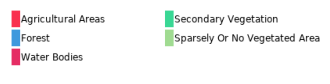

In [31]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import rsgislib.tools.plotting as rsg_plot

# ------------------------------------------------------------------
# 1. Build legend's dictionary based on raster
#    (ajusta 'class_names' si tu campo tiene otro nombre)
# ------------------------------------------------------------------
cls_info = rsg_plot.create_legend_info_dict(
    out_cls_img,
    cls_names_col="class_names",
    use_title_case=True,
    underscore_to_space=True,
)

# ------------------------------------------------------------------
# 2. Localizar una fuente TrueType que sí exista
#    DejaVu Sans viene con Matplotlib y está en casi todos los entornos
# ------------------------------------------------------------------
font_path = fm.findfont("DejaVu Sans", fallback_to_default=True)

# ------------------------------------------------------------------
# 3. Dibujar la leyenda sobre un eje Matplotlib
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(4, 4))

rsg_plot.create_legend_img_mpl_ax(
    ax,
    legend_info=cls_info,
    n_cols=2,          # número de columnas de la leyenda
    font=font_path,    # ruta TTF garantizada
)
plt.show()

Image Data Size: 2783 x 3339
Image Data Size: 2783 x 3339
Max. characters in class name: 30
Column width: 192
Image: 396 x  82


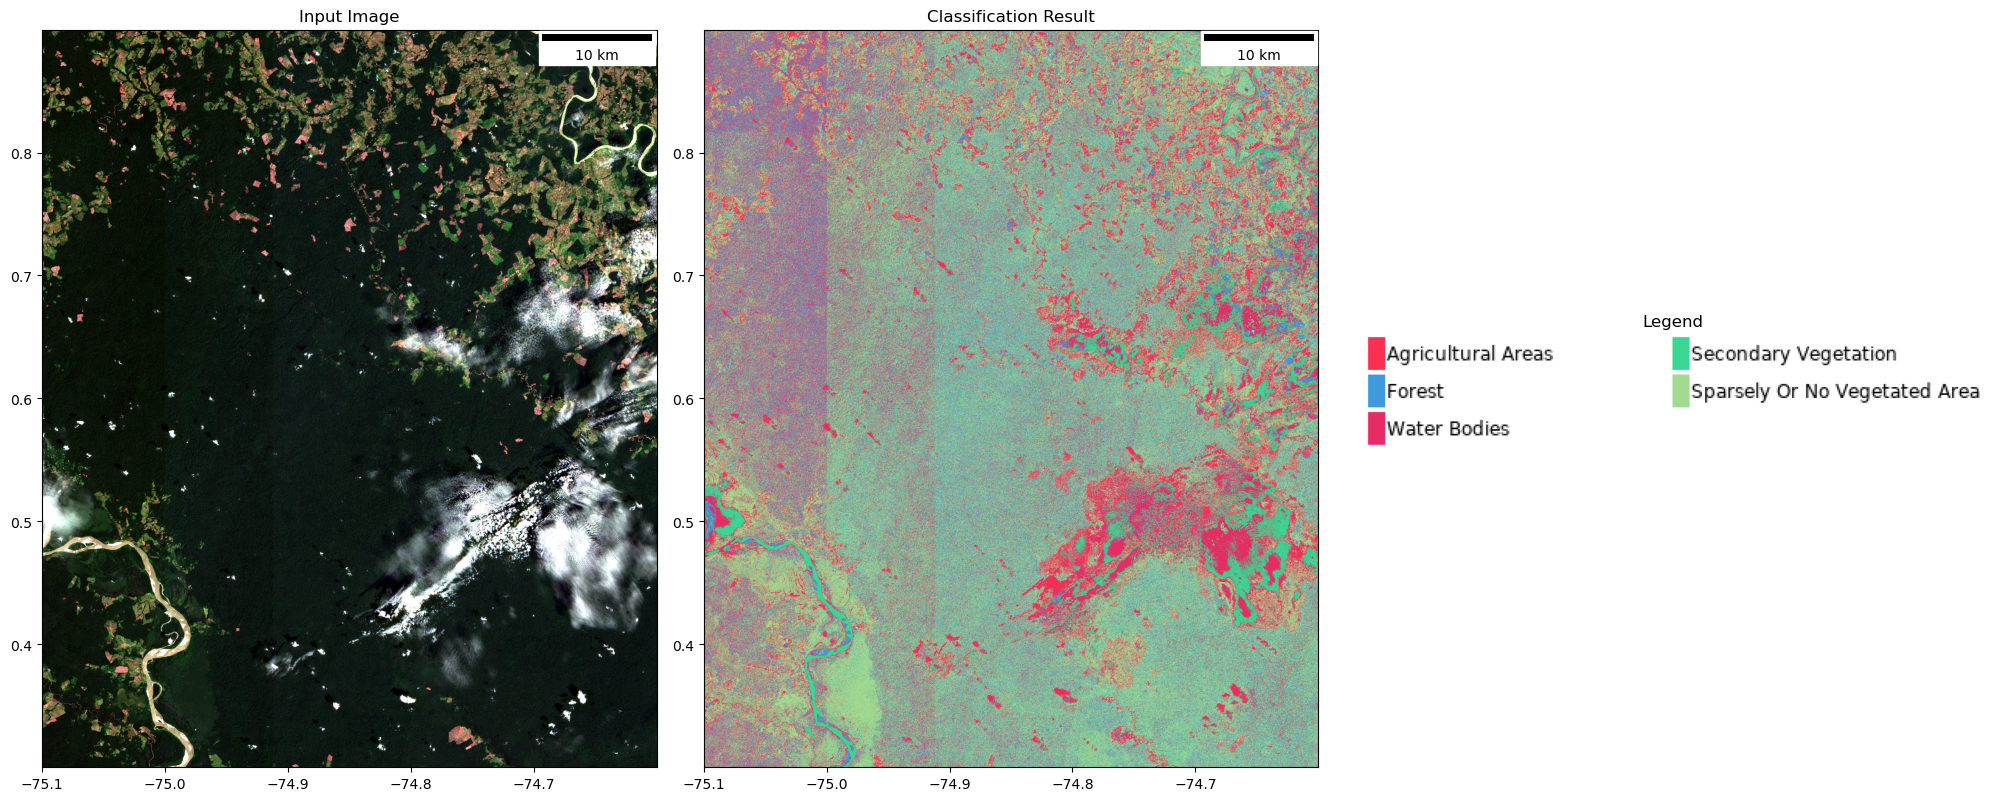

In [32]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import rsgislib.tools.mapping as rsg_map
import rsgislib.tools.plotting as rsg_plot

# ------------------------------------------------------------
# 1. Legend dictionary (already created earlier as `cls_info`)
#    cls_info = rsg_plot.create_legend_info_dict(...)
# ------------------------------------------------------------

# 2. Find a reliable TrueType font (DejaVu Sans ships with Matplotlib)
font_path = fm.findfont("DejaVu Sans", fallback_to_default=True)

# 3. Build a 3-panel figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 8), sharey=False)

# ---- Sentinel-2 RGB composite (bands 8-9-3) ----
rsg_map.create_raster_img_map(
    ax1,
    input_img,                       # Sentinel-2 subset (KEA / GeoTIFF)
    img_bands=[3, 2, 1],
    img_stch=rsgislib.IMG_STRETCH_CUMULATIVE,
    bbox=sub_img_bbox,
    show_scale_bar=True,
)
ax1.set_title("Input Image")

# ---- Pixel-based classification map ----
rsg_map.create_thematic_raster_map(
    ax2,
    out_cls_img,                     # Classified raster
    bbox=sub_img_bbox
)
ax2.set_title("Classification Result")

# ---- Legend panel (font argument prevents OSError) ----
rsg_plot.create_legend_img_mpl_ax(
    ax3,
    legend_info=cls_info,
    n_cols=2,                        # Columns in the legend table
    font=font_path                   # Explicit TTF path → no “cannot open resource”
)
ax3.set_title("Legend")

plt.tight_layout()
plt.show()
